In [1]:
%load_ext autoreload
%autoreload 2

from pyvtna.readers import ManualInput, ExcelReader
from pyvtna.vtna import VTNA
from pyvtna.testing import simulate_reaction_trace
from pyvtna.visualizers import StaticPlotter
from pyvtna.signal import replace_neg
import numpy as np
import matplotlib.pyplot as plt
import itertools

## Generating Dummy Data

For testing purposes, let's generate some fake data for the reaction:

$$2NO + O_2 \longrightarrow 2NO_2,  Rate=k[NO]^2[O_2]$$

We don't care about absolute rates, so we will just set k = 1

In [431]:
np.random.seed(0)
time = np.linspace(0, 1600, 100)
k = 0.001

# order reactants as [NO, O2]
reac_st = [2., 1.]
reac_orders = [2, 1]
reac_coefs = [2., 1.]
prod_st = [0.]
prod_coefs = [2]
noise = 0.02

[NO, O2], [NO2] = simulate_reaction_trace(time, reac_st, reac_orders, reac_coefs, 
                                           prod_st, prod_coefs, k=k, noise=noise)

## Differing Starting Concentrations
Now let's simulate a second run of the reaction, but with the starting concentration of NO doubled, as if running a series of rate experiments

In [432]:
time2 = np.linspace(0, 3000, 100)
reac_st = [1.3, 1.]
[NO_b, O2_b], [NO2_b] = simulate_reaction_trace(time2, reac_st, reac_orders, reac_coefs, 
                                                prod_st, prod_coefs, k=k, noise=noise)

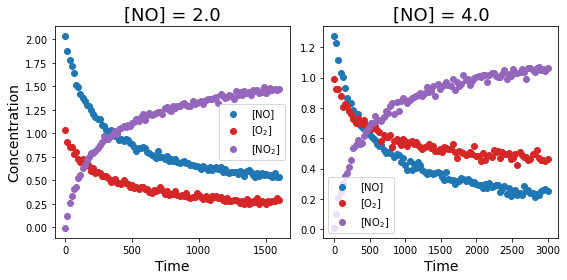

In [433]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.scatter(time, NO, c='tab:blue', label="[NO]")
ax1.scatter(time, O2, c='tab:red', label="[O$_2$]")
ax1.scatter(time, NO2, c='tab:purple', label="[NO$_2$]")
ax1.legend()
ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Concentration', fontsize=14)
ax1.set_title('[NO] = 2.0', fontsize=18)

ax2.scatter(time2, NO_b, c='tab:blue', label="[NO]")
ax2.scatter(time2, O2_b, c='tab:red', label="[O$_2$]")
ax2.scatter(time2, NO2_b, c='tab:purple', label="[NO$_2$]")
ax2.legend()
ax2.set_xlabel('Time', fontsize=14)
ax2.set_title('[NO] = 4.0', fontsize=18)

plt.tight_layout()
plt.show()

## Try the Auto-Fit

Best fit achieved for parameter value of 2.00.


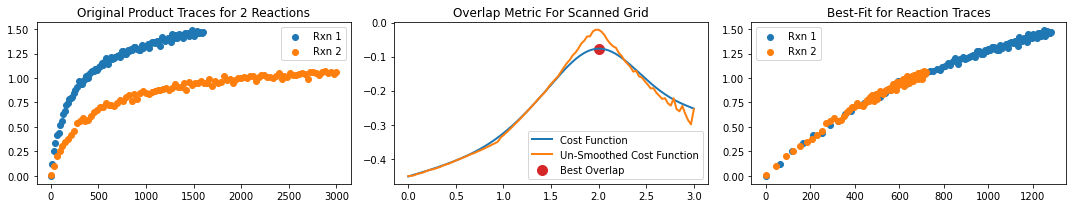

Best fit achieved for parameter value of 1.97.


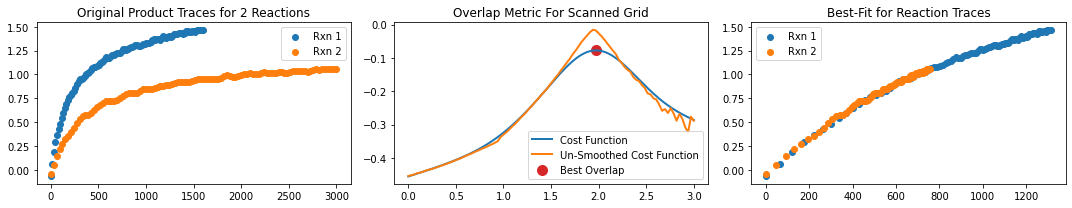

In [434]:
rxn1 = np.concatenate([time[:, np.newaxis], NO[:, np.newaxis], O2[:, np.newaxis], NO2[:, np.newaxis]], axis=1)
rxn2 = np.concatenate([time2[:, np.newaxis], NO_b[:, np.newaxis], O2_b[:, np.newaxis], NO2_b[:, np.newaxis]], axis=1)
reaction_data = ManualInput(data={"rxn_1": rxn1, "rxn_2": rxn2}, species_names='NO O2 NO2'.split())
visualizer = StaticPlotter(figsize=(15, 3))

vtna_experiment = VTNA(reaction_data, visualizer=visualizer)
besto, rs, f = vtna_experiment.order_search('rxn_1', 'rxn_2', 'NO2', 'NO')

# Try smoothing the data
vtna_experiment.smooth_data()
vtna_experiment.visualizer.reset_fig()
besto, rs, f = vtna_experiment.order_search('rxn_1', 'rxn_2', 'NO2', 'NO')

# un-smooth for future work
vtna_experiment.data.reset_reaction_traces()

## Now for the Second Reactant

Using autofit, we see that the order for NO is approximately 2. Let's normalize the time with this, then fit for the order of the second reactant, O$_2$.

In [404]:
vtna_experiment.set_reactant_order('NO', 2)

To fit for the remaining reactant order, we can do just a first order search to find the order that normalizes the trace to a straight line. This is handled by the `VTNA` class. We do it for both reactions. They should both produce optimal orders of 1.

Best fit achieved for parameter value of 1.03.


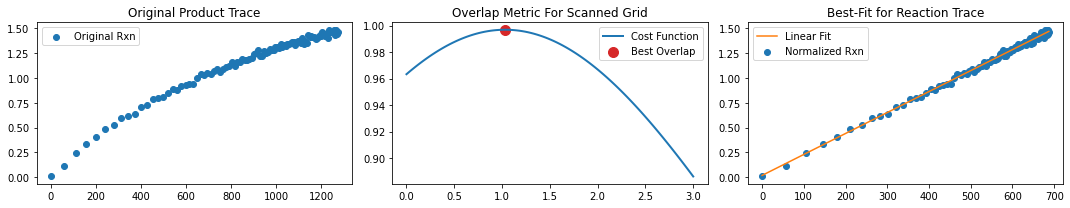

In [405]:
vtna_experiment.visualizer.reset_fig()
handle_neg = lambda x: replace_neg(x, 0)

o2_order, scores, f, slope = vtna_experiment.order_search_single_trace('rxn_1', 'NO2', 'O2', handle_neg=handle_neg)

## Obtaining the Rate Constant

The rate constant $k$ in the above reaction 

$$2NO + O_2 \longrightarrow 2NO_2,  Rate=k[NO]^2[O_2]$$

can be obtained from the slope of the resulting line. Note that in this case, since the species we are monitoring is NO$_2$, we need to divide the slope by 2 to obtain the actual rate constant, to account for the stoichiometry in the reaction (coefficient of 2 on NO$_2$). Thus, we recover a rate constant of:

In [406]:
slope / 2 

0.0010561610314425653

which is very close to the rate constant used in simulating the data ($k$ = 0.001).

We can repeat the normalization with the second reaction trace to validate results or obtain an average.

Best fit achieved for parameter value of 1.27.


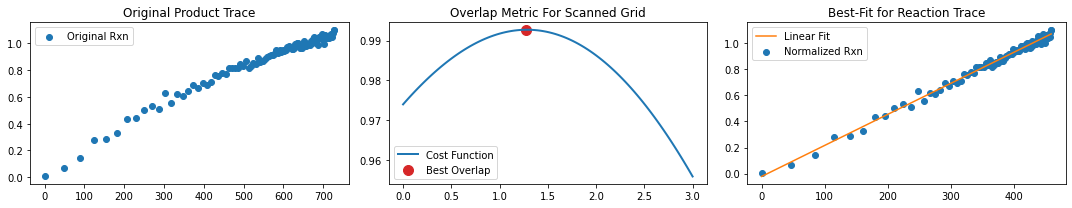

In [407]:
vtna_experiment.visualizer.reset_fig()
o2_order, scores, f, slope = vtna_experiment.order_search_single_trace('rxn_2', 'NO2', 'O2', handle_neg=handle_neg)

In [408]:
slope / 2

0.001190548605703128

In [409]:
vtna_experiment.set_reactant_order('O2', 1)

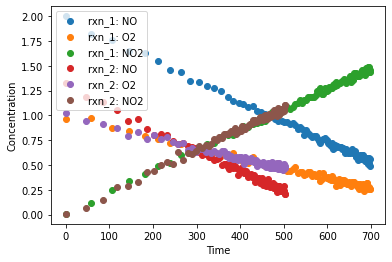

In [410]:
StaticPlotter.plot_traces(vtna_experiment.data)

As hoped for, the order of [O$_2$] is found to be $\approx$ 1 in both reactions. Now, we can plot the steps to reaction normalization for each reaction.

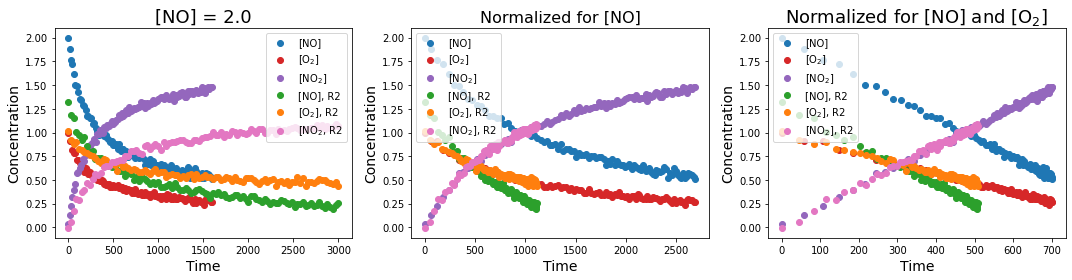

In [346]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.scatter(time, NO, c='tab:blue', label="[NO]")
ax1.scatter(time, O2, c='tab:red', label="[O$_2$]")
ax1.scatter(time, NO2, c='tab:purple', label="[NO$_2$]")
ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Concentration', fontsize=14)
ax1.set_title('[NO] = 2.0', fontsize=18)

ax1.scatter(time2, NO_b, c='tab:green', label="[NO], R2")
ax1.scatter(time2, O2_b, c='tab:orange', label="[O$_2$], R2")
ax1.scatter(time2, NO2_b, c='tab:pink', label="[NO$_2$, R2")
ax1.legend()
ax1.set_xlabel('Time', fontsize=14)


vtna_experiment.set_reactant_order('O2', -1)
t1_norm_NO = vtna_experiment.data.reaction_traces['rxn_1'][:, 0]
t2_norm_NO = vtna_experiment.data.reaction_traces['rxn_2'][:, 0]

# First Normalization Step -- NO order 2
ax2.scatter(t1_norm_NO, NO, c='tab:blue', label="[NO]")
ax2.scatter(t1_norm_NO, O2, c='tab:red', label="[O$_2$]")
ax2.scatter(t1_norm_NO, NO2, c='tab:purple', label="[NO$_2$]")
ax2.set_xlabel('Time', fontsize=14)
ax2.set_ylabel('Concentration', fontsize=14)
ax2.set_title('Normalized for [NO]', fontsize=16)

ax2.scatter(t2_norm_NO, NO_b, c='tab:green', label="[NO], R2")
ax2.scatter(t2_norm_NO, O2_b, c='tab:orange', label="[O$_2$], R2")
ax2.scatter(t2_norm_NO, NO2_b, c='tab:pink', label="[NO$_2$], R2")
ax2.set_xlabel('Time', fontsize=14)
ax2.legend()

vtna_experiment.set_reactant_order('O2', 1)
t1_norm_NO_O2 = vtna_experiment.data.reaction_traces['rxn_1'][:, 0]
t2_norm_NO_O2 = vtna_experiment.data.reaction_traces['rxn_2'][:, 0]

# Second Normalization Step -- O2 order 1
ax3.scatter(t1_norm_NO_O2, NO, c='tab:blue', label="[NO]")
ax3.scatter(t1_norm_NO_O2, O2, c='tab:red', label="[O$_2$]")
ax3.scatter(t1_norm_NO_O2, NO2, c='tab:purple', label="[NO$_2$]")
ax3.set_xlabel('Time', fontsize=14)
ax3.set_ylabel('Concentration', fontsize=14)
ax3.set_title('Normalized for [NO] and [O$_2$]', fontsize=16)

ax3.scatter(t2_norm_NO_O2, NO_b, c='tab:green', label="[NO], R2")
ax3.scatter(t2_norm_NO_O2, O2_b, c='tab:orange', label="[O$_2$], R2")
ax3.scatter(t2_norm_NO_O2, NO2_b, c='tab:pink', label="[NO$_2$], R2")
ax3.set_xlabel('Time', fontsize=14)
ax3.set_title('Normalized for [NO] and [O$_2$]', fontsize=18)
ax3.legend()

plt.tight_layout()
plt.show()

# Read in Reaction Data from Excel File

In [62]:
hydroamination = ExcelReader("sampledata/Hydroamination-Kinetics-Catalyst-Order.xlsx")
hydroam_vtna = VTNA(hydroamination, visualizer=StaticPlotter(figsize=(15,3)))
hydroam_vtna.update_species_name('c/c0', 'reactant')

for i, old_name in enumerate(hydroam_vtna.data.reaction_names):
    hydroam_vtna.update_reaction_name(old_name, f'rxn_{i+1}')

cat_concs = [0.051, 0.0578, 0.0688, 0.075, 0.104, 0.125, 0.127, 0.142]
cat_concs_dict = {rxn_name: cat_conc for (rxn_name, cat_conc) in zip(hydroam_vtna.data.reaction_names, cat_concs)}

hydroam_vtna.add_catalysts(cat_concs_dict)

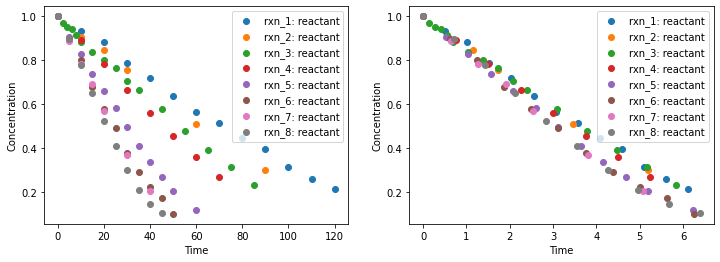

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
StaticPlotter.plot_traces(hydroam_vtna.data, reaction_names=None, species_names=['reactant'], ax=ax1)

# normalize by catalyst concentration with known order (1)
hydroam_vtna.set_reactant_order('catalyst', 1)
StaticPlotter.plot_traces(hydroam_vtna.data, reaction_names=None, species_names=['reactant'], ax=ax2)
plt.show()

## Now try the Auto-fit

Use the `order_opt` function with all possible pairs of reaction traces. Average to get the optimal order.

In [99]:
# turn off the plotting for this run
hydroam_vtna.visualizer = None

# reset the order
hydroam_vtna.set_reactant_order('catalyst', 0)

orders = []
# try to normalize each available pair of reaction traces
for combo in itertools.combinations(range(len(hydroamination.reaction_traces)), 2):
    rxn_1, rxn_2 = f"rxn_{combo[0] + 1}", f"rxn_{combo[1] + 1}"
    result, history = hydroam_vtna.order_opt(rxn_1, rxn_2, 'reactant', 'catalyst', o_range=(0, 3))
    orders.append(result.x[0])

orders.pop(-3)  # This corresponds to rxns 6 and 7, which have the same starting concentration, so VTNA won't work
order = sum(orders) / len(orders)
print(f"The catalyst order was determined to be {order:0.2f} by auto-fitting.")

The catalyst order was determined to be 1.21 by auto-fitting.


In [33]:
hydroam_vtna.set_reactant_order('catalyst', 1)
ks = []
for rxn in hydroam_vtna.data.reaction_names:
    ks.append(-hydroam_vtna.get_average_slope(rxn, 'reactant'))
hydroam_vtna.set_rate_constant(np.mean(ks))
hydroam_vtna.pprint_rate_law()

Rate =  1.42e-01[catalyst]^1


## Fitting Poisoning

This is the procedure we will use to fit the catalyst poisoning:

* Set the order to some value, and then maximize the reaction trace overlap by varying the assumed poison value
    - A 1D optimization

One might also try an alternative approach:
*  Maximize the reaction trace overlap over both the order and the poisoning.
    - A 2D optimization
    
However, this does not work as anticipated. Unfortunately, there will generally be corresponding values of order and poisoning that produce the same fits. This is illustrated below, where it is shown that we can get a good fit for order even when poisoning is neglected...the order is just higher than the actual order. In fact, the goodness of fit is the same in both cases, meaning a 2D optimization will not discriminate between the two, even though the one with order 1 and poisoning 0.5 is correct.

In fact, this second option could be used, but only with a more complicated implementation that considers more than two traces. Notice above that the optimal order shifts depending on the reactions compared. Maximizing the collective goodness of fit of all of the above traces over poisoning and catalyst order could seemingly give a uniquely best answer.

## Fit the Poisoning with Order Set to 1

In [98]:
hydroam_vtna.set_reactant_order('catalyst', 0)
hydroam_vtna.set_overlap_metric('RMSD')
poisons = []
order = 1
hydroam_vtna.visualizer = None

for combo in itertools.combinations(range(8), 2):
    rxn_1, rxn_2 = hydroam_vtna.data.reaction_names[combo[0]], hydroam_vtna.data.reaction_names[combo[1]]
    pois, costs, f = hydroam_vtna.poison_search(rxn_1, rxn_2, 'reactant', 'catalyst', order, poison_range=(0, 0.025))
    poisons.append(pois)
print(f"The catalyst poisoning was determined to be {np.mean(poisons):0.4f} by auto-fitting.")

The catalyst poisoning was determined to be 0.0146 by auto-fitting.


## Try a 2D Fit Over All Traces

As seen, this assesment finds a fit with no poisoning, but an order of 1.23, even though the reaction kinetics are believed to be first order in catalyst. 

It appears that for small values of poisoning relative to the catalyst concentrations, may often be the case, though further investigation is required. As seen later in this notebook, it is still possible to fit both poisoning and order simultaneously when the poisoning is rather large.

Best fit achieved for order: 1.23, posioning: 0.0000.


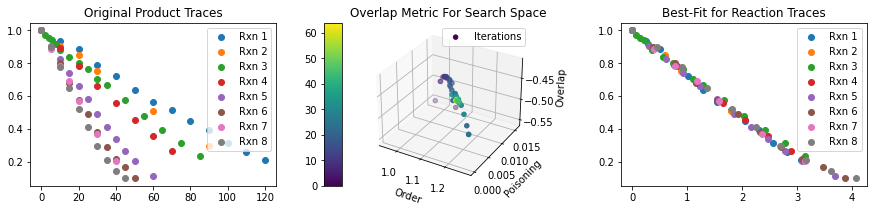

In [103]:
hydroam_vtna.set_reactant_order('catalyst', 0)
hydroam_vtna.visualizer = StaticPlotter(figsize=(15, 3))

result, history = hydroam_vtna.order_poison_opt('reactant', 'catalyst', rxns=None, o_range=(0, 2), poison_range=(0.0, 0.03))

## Simulate Catalyzed Reaction

To simulate a catalyzed reaction, we can use the same function `simulate_reaction_trace` as before. The trick is to simply set the coefficient of the catalyst species to 0, while giving it a reaction order just like any other species. This will mean that the concentration appears in the rate law but not in the balanced chemical reaction, thereby enforcing a constant concentration throughout the reaction trace.

Catalyst poisoning can also be introduced by simply subtracting some set concentration of catalyst from the starting concentration and passing this diminished value to the `simulate_reaction_trace` function. Thus, the nominal catalyst concentration is slightly higher than the concentration actually available for chemical reaction.

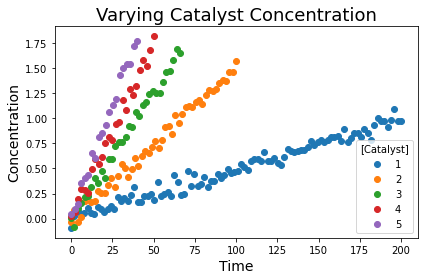

In [70]:
# time = np.linspace(0, 200, 2000)
k = 0.01

# order reactants as [NO, O2]
reac_st = [2., 2., 1.]
reac_orders = [0., 0., 1.]
reac_coefs = [1., 1., 0.]
prod_st = [0.]
prod_coefs = [1.]
noise = 0.05
poisoning = 0.5

fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))

rxn_traces = {}
for cat_conc in [1, 2, 3, 4, 5]:
    reac_st[-1] = cat_conc - poisoning
    
    time = np.linspace(0, 200//cat_conc, 100//cat_conc)
    
    [r1, r2, _], [p1] = simulate_reaction_trace(time, reac_st, reac_orders, reac_coefs, 
                                                 prod_st, prod_coefs, k=k, noise=noise)
    c1 = np.ones(r1.shape) * cat_conc
    rxn_traces[str(cat_conc)] = np.c_[time, r1, r2, c1, p1]
    ax1.scatter(time, p1, label=f"{cat_conc}")

ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Concentration', fontsize=14)
ax1.set_title('Varying Catalyst Concentration', fontsize=18)
ax1.legend(title='[Catalyst]')
plt.tight_layout()
plt.show()

## Set it up as a VTNA experiment

In [106]:
cat_rxn_data = ManualInput(data=rxn_traces, species_names='r1 r2 c p1'.split())
visualizer = StaticPlotter(figsize=(15, 4))
vtna_cat = VTNA(cat_rxn_data, visualizer=None)

## Fit Order With No Consideration of Poisoning

In [107]:
orders = []

for combo in itertools.combinations(range(5), 2):
    visualizer.reset_fig()
    rxn_1, rxn_2 = vtna_cat.data.reaction_names[combo[0]], vtna_cat.data.reaction_names[combo[1]]
    
    result, history = vtna_cat.order_opt(rxn_1, rxn_2, 'p1', 'c', o_range=(0, 2.5))
    orders.append(result.x[0])

order = sum(orders) / len(orders)
print(f"The catalyst order was determined to be {order:0.2f} by auto-fitting.")

The catalyst order was determined to be 1.30 by auto-fitting.


## 2D Fitting of Both Order and Poisoning

Best fit achieved for order: 1.01, posioning: 0.5159.


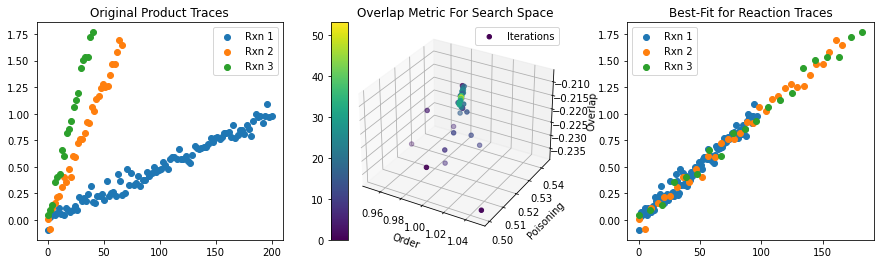

In [108]:
vtna_cat.visualizer = visualizer
visualizer.reset_fig()
result, history = vtna_cat.order_poison_opt('p1', 'c', rxns=['1', '3', '5'], o_range=(0, 2), poison_range=(0, 1))

## Poison Fitting With Order FIxed at 1

Let's try the other option, where the order is fixed and only poisoning allowed to vary. The order found above, even when not correcting for poisoning, is approximately 1. Let's assume that the reaction is in fact first order in the catalyst. Then we search for the poisoning value (let's limit it to be between zero and the lowest catalyst concentration so we do not end up with negative values) that maximizes the reaction trace overlap, given an order of 1.

In [426]:
vtna_cat.set_species_poisoning('c', 0)

Best fit achieved for parameter value of 0.49.


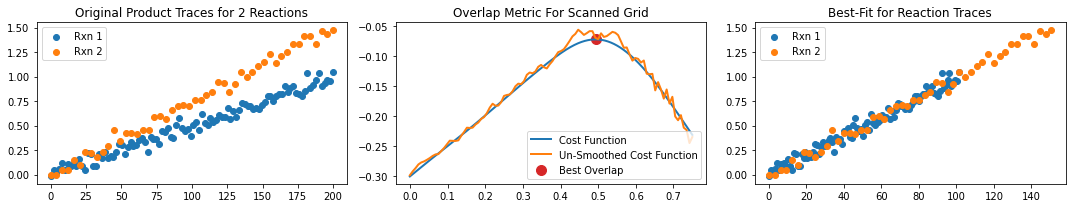

Best fit achieved for parameter value of 0.50.


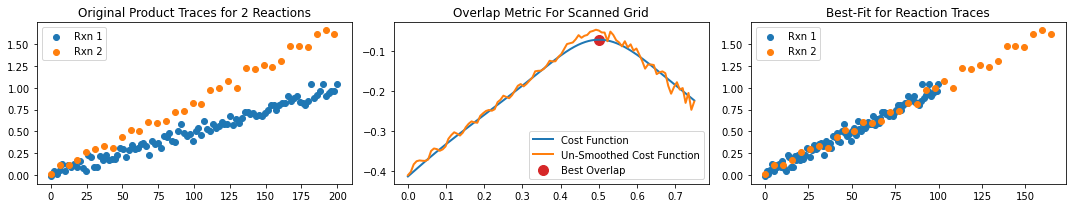

Best fit achieved for parameter value of 0.50.


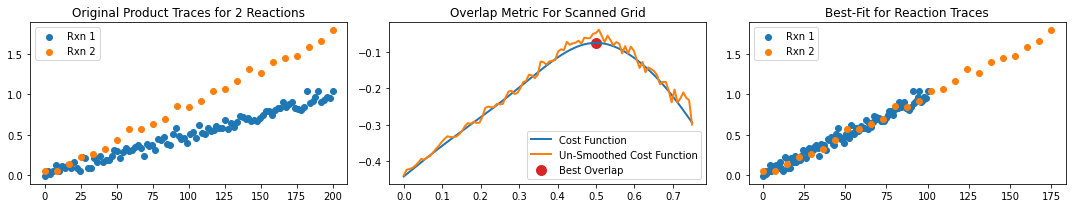

Best fit achieved for parameter value of 0.51.


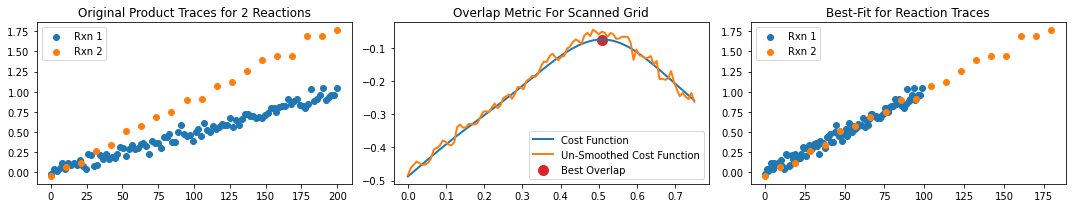

Best fit achieved for parameter value of 0.49.


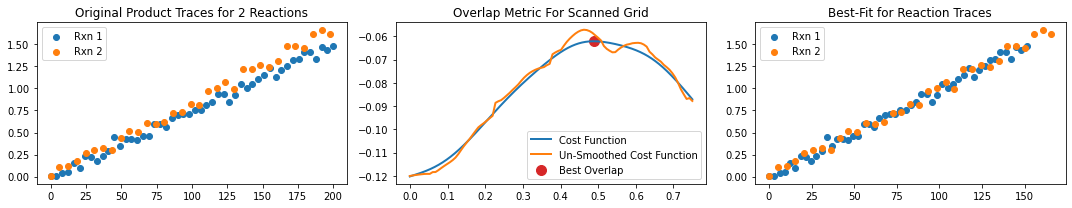

Best fit achieved for parameter value of 0.51.


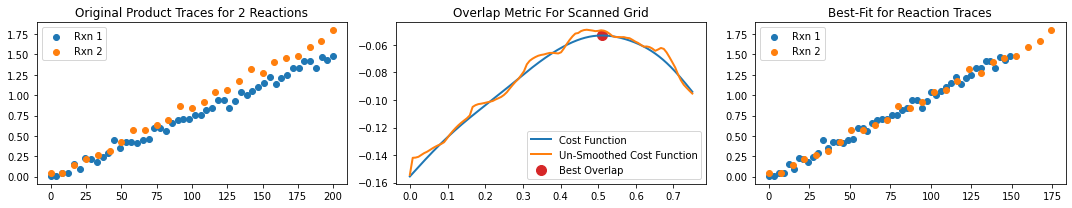

Best fit achieved for parameter value of 0.54.


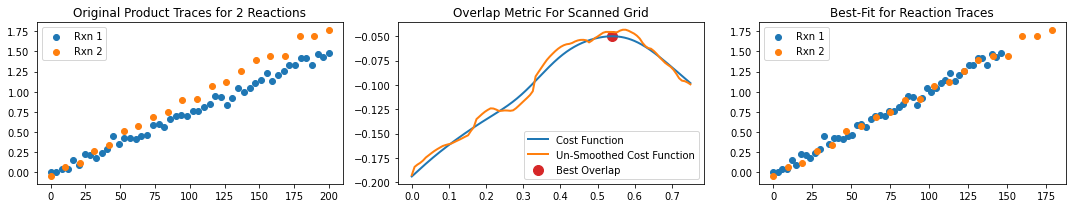

Best fit achieved for parameter value of 0.33.


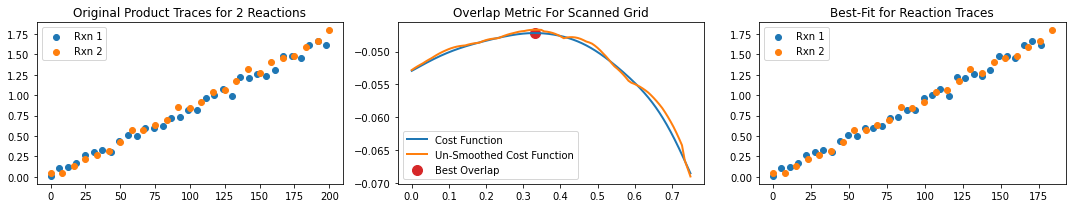

Best fit achieved for parameter value of 0.41.


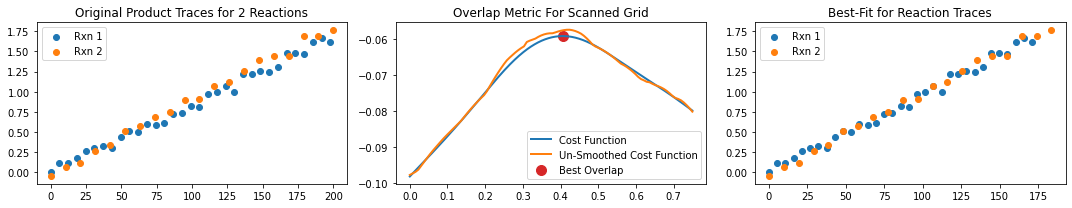

Best fit achieved for parameter value of 0.63.


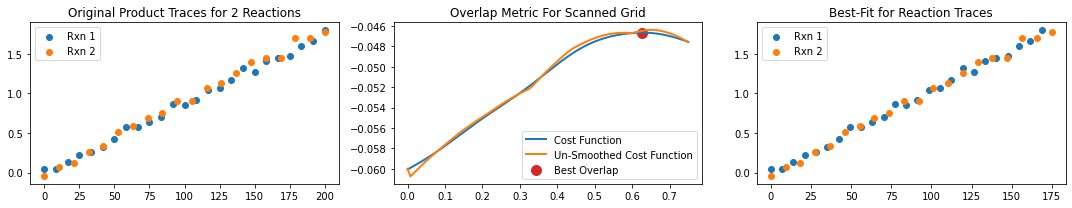

In [427]:
poisons = []
order = 1

for combo in itertools.combinations(range(5), 2):
    vtna_cat.visualizer.reset_fig()
    rxn_1, rxn_2 = vtna_cat.data.reaction_names[combo[0]], vtna_cat.data.reaction_names[combo[1]]
    pois, costs, f = vtna_cat.poison_search(rxn_1, rxn_2, 'p1', 'c', order, poison_range=(0, 0.75))
    poisons.append(pois)

In [428]:
print(f"Grid Search: Average catalyst poisoning calculated to be {sum(poisons) / len(poisons):0.2f}.",
        f"\nActual Poisoning in simulated reaction traces was {poisoning}.")

Grid Search: Average catalyst poisoning calculated to be 0.49. 
Actual Poisoning in simulated reaction traces was 0.5.


## Now Try with the Faster Optimization Algorithm

Best fit achieved for an parameter value of 0.48.


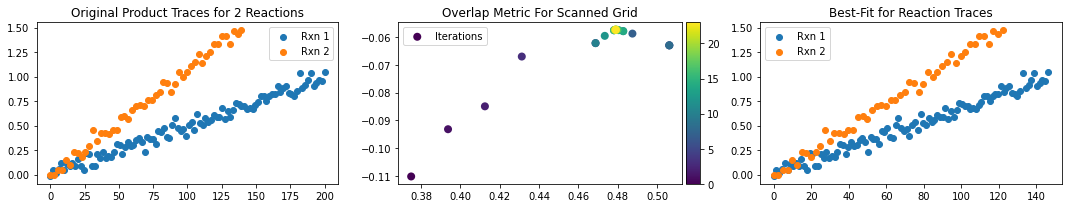

Best fit achieved for an parameter value of 0.49.


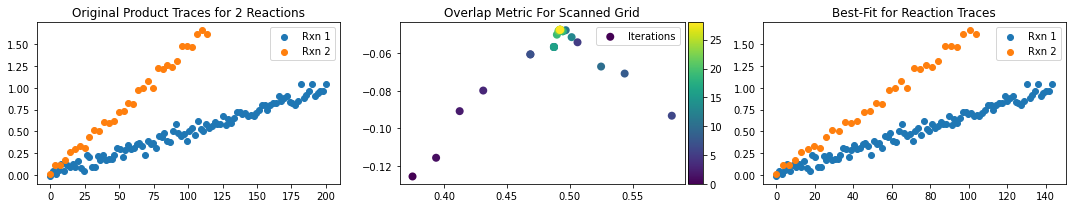

Best fit achieved for an parameter value of 0.51.


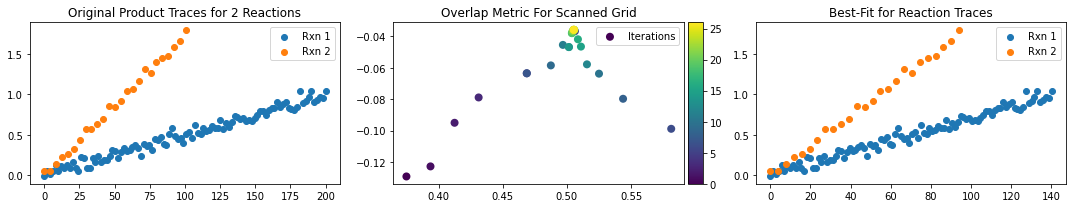

Best fit achieved for an parameter value of 0.38.


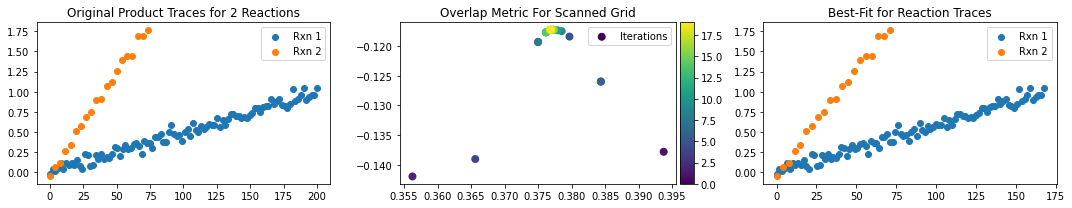

Best fit achieved for an parameter value of 0.46.


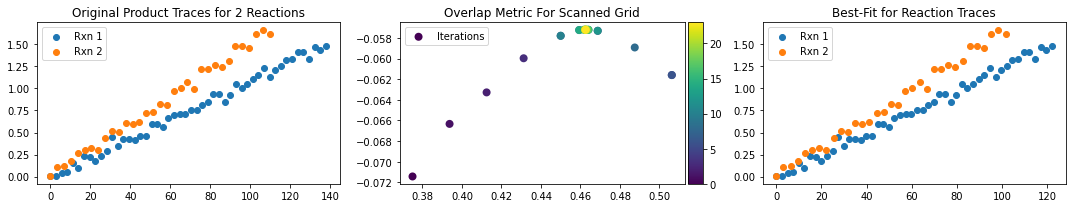

Best fit achieved for an parameter value of 0.38.


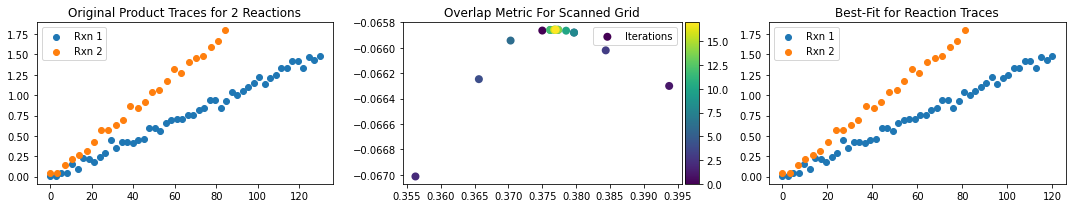

Best fit achieved for an parameter value of 0.57.


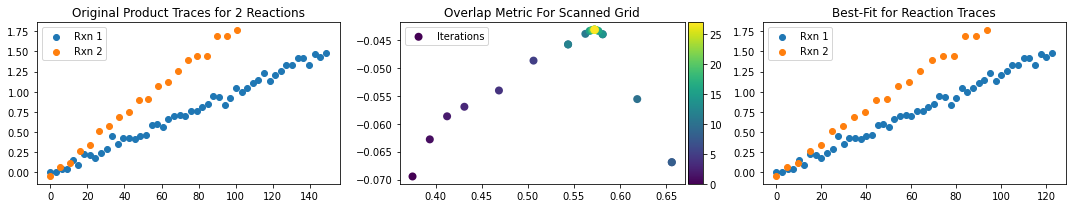

Best fit achieved for an parameter value of 0.34.


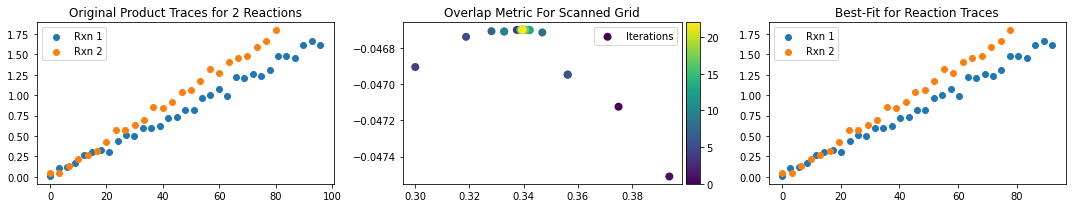

Best fit achieved for an parameter value of 0.42.


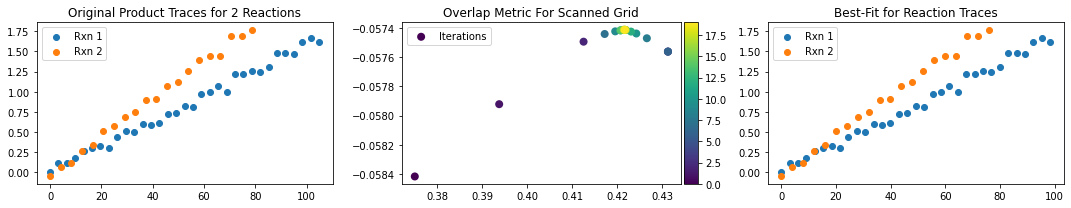

Best fit achieved for an parameter value of 0.65.


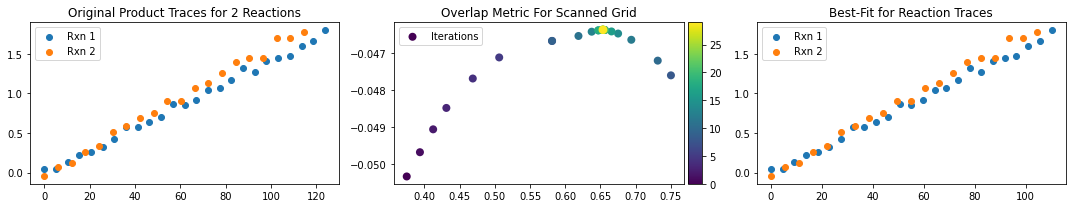

In [429]:
poisons = []
order = 1

for combo in itertools.combinations(range(5), 2):
    vtna_cat.visualizer.reset_fig()
    rxn_1, rxn_2 = vtna_cat.data.reaction_names[combo[0]], vtna_cat.data.reaction_names[combo[1]]
    res, history = vtna_cat.poison_opt(rxn_1, rxn_2, 'p1', 'c', order, poison_range=(0, 0.75))
    poisons.append(res.x[0])

In [430]:
# Without smoothing: Average Poisoning Calculated to be 0.46
# With smoothing: 
print(f"Opt: Average catalyst poisoning calculated to be {sum(poisons) / len(poisons):0.2f}.",
        f" Actual Poisoning in simulated reaction traces was {poisoning}.")

Opt: Average catalyst poisoning calculated to be 0.47.  Actual Poisoning in simulated reaction traces was 0.5.
